In [1]:
import os
import pandas as pd
import numpy as np
import pefile
from tqdm import tqdm

In [2]:
MALWARE_DIR = "../malware_samples"

files = os.listdir(MALWARE_DIR)
len(files)

40

In [3]:
files[:10]

['JH78C0A33A1B472A8C16123FD696A5CE5EBB',
 'AAAz2E1B6940985A23E5639450F8391820655',
 '650A6FCA433EE243391E4B4C11F09438',
 'JKK8CA6FE7A1315AF5AFEAC2961460A80569',
 'VBMM9_149B7BD7218AAB4E257D28469FDDB0D',
 'SAM_B659D71AE168E774FAAF38DB30F4A84',
 'KLp90_6D5C8FC4B14559F73B6136D85B94198',
 'B98hX8E8622C393D7E832D39E620EAD5D3B49',
 'F8437E44748D2C3FCF84019766F4E6DC',
 'F6655E39465C2FF5B016980D918EA028']

In [4]:
# Creación de función que extrae features

def extract_features(filepath):
    
    features = {}
    
    try:
        pe = pefile.PE(filepath)
        
        # número de secciones
        features["num_sections"] = len(pe.sections)
        
        # tamaño del archivo
        features["file_size"] = os.path.getsize(filepath)
        
        # número de imports
        num_imports = 0
        
        if hasattr(pe, "DIRECTORY_ENTRY_IMPORT"):
            for entry in pe.DIRECTORY_ENTRY_IMPORT:
                num_imports += len(entry.imports)
        
        features["num_imports"] = num_imports
        
    except:
        # si no se puede analizar PE
        features["num_sections"] = 0
        features["file_size"] = 0
        features["num_imports"] = 0
    
    return features

In [5]:
# Construir el dataset

data = []

for f in tqdm(files):
    
    path = os.path.join(MALWARE_DIR, f)
    
    features = extract_features(path)
    
    features["sample"] = f
    
    data.append(features)

df = pd.DataFrame(data)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 351.05it/s]


In [6]:
# Ver el dataset

df.head()

,num_sections,file_size,num_imports,sample
0,3,5632,8,JH78C0A33A1B472A8C16123FD696A5CE5EBB
1,3,344576,10,AAAz2E1B6940985A23E5639450F8391820655
2,3,5632,8,650A6FCA433EE243391E4B4C11F09438
3,3,5632,8,JKK8CA6FE7A1315AF5AFEAC2961460A80569
4,3,14336,8,VBMM9_149B7BD7218AAB4E257D28469FDDB0D


In [7]:
# Guardar el dataset

df.to_csv("../dataset/malware_dataset.csv", index=False)

In [8]:
# Extracción de strings

import subprocess

def extract_strings(filepath):
    
    try:
        result = subprocess.check_output(["strings", filepath])
        strings = result.decode("utf-8", errors="ignore")
        return strings
        
    except:
        return ""

In [9]:
# Extracción de funciones importadas

def extract_functions(filepath):
    
    functions = []
    
    try:
        pe = pefile.PE(filepath)
        
        if hasattr(pe, "DIRECTORY_ENTRY_IMPORT"):
            for entry in pe.DIRECTORY_ENTRY_IMPORT:
                for imp in entry.imports:
                    if imp.name:
                        functions.append(imp.name.decode())
    
    except:
        pass
    
    return " ".join(functions)

In [10]:
# Reconstruir el dataset completo

data = []

for f in tqdm(files):

    path = os.path.join(MALWARE_DIR, f)

    features = extract_features(path)

    features["sample"] = f
    features["strings"] = extract_strings(path)
    features["functions"] = extract_functions(path)

    data.append(features)

df = pd.DataFrame(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 80.20it/s]


In [11]:
# Guardar el dataset final

df.to_csv("../dataset/malware_dataset.csv", index=False)

In [12]:
df["text_features"] = df["strings"] + " " + df["functions"]

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_text = vectorizer.fit_transform(df["text_features"])

In [14]:
import numpy as np

numeric_features = df[["num_sections", "num_imports", "file_size"]].values

In [15]:
from scipy.sparse import hstack

X = hstack([X_text, numeric_features])

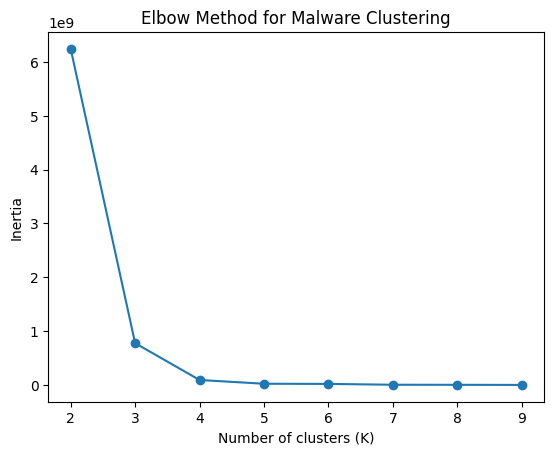

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Malware Clustering")
plt.show()